<a href="https://colab.research.google.com/github/sreejareddy-24/celebal/blob/main/week4_sreeja_reddy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2912s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

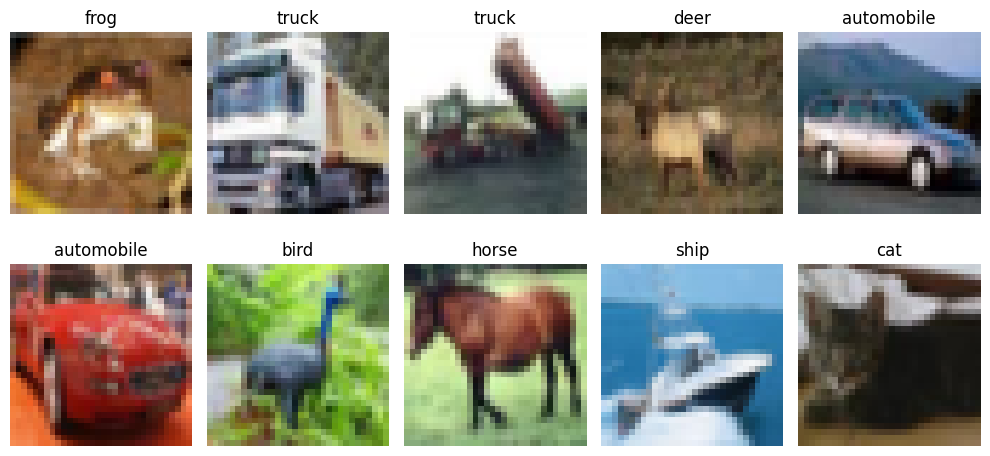

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.2743 - loss: 1.9873 - val_accuracy: 0.3286 - val_loss: 1.8570
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3154 - loss: 1.8691 - val_accuracy: 0.3628 - val_loss: 1.7962
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3452 - loss: 1.8057 - val_accuracy: 0.3794 - val_loss: 1.7513
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.3534 - loss: 1.7891 - val_accuracy: 0.3974 - val_loss: 1.7237
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3645 - loss: 1.7497 - val_accuracy: 0.4030 - val_loss: 1.7204
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3784 - loss: 1.7220 - val_accuracy: 0.4194 - val_loss: 1.6646
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3833 - loss: 1.7030 - val_accuracy: 0.3930 - val_loss: 1.6892
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3889 - loss: 1.6901 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4340 - loss: 1.6075
ANN Test Accuracy: 0.4339999854564667


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 79ms/step - accuracy: 0.4700 - loss: 1.4979 - val_accuracy: 0.4780 - val_loss: 1.5478
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 85ms/step - accuracy: 0.6140 - loss: 1.1052 - val_accuracy: 0.5928 - val_loss: 1.2082
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 80ms/step - accuracy: 0.6736 - loss: 0.9363 - val_accuracy: 0.5952 - val_loss: 1.1535
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.7163 - loss: 0.8186 - val_accuracy: 0.6624 - val_loss: 1.0066
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.7470 - loss: 0.7225 - val_accuracy: 0.7050 - val_loss: 0.8483
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 82ms/step - accuracy: 0.7744 - loss: 0.6501 - val_accuracy: 0.6558 - val_loss: 1.0706
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7960 - loss: 0.5848 - val_accuracy: 0.7038 - val_loss: 0.9102
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.8149 - loss: 0.5218 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7232 - loss: 0.8887
CNN Test Accuracy: 0.7232000231742859


## 📈 Compare Learning Curves

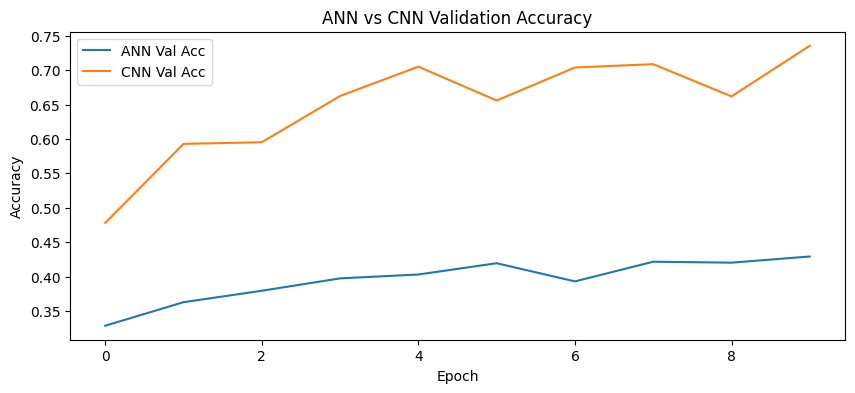

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4340
1,CNN,0.7232


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [12]:
deep_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_acc = deep_ann.evaluate(x_test_flat, y_test)[1]

print("Deep ANN Accuracy:", deep_ann_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.3059 - loss: 1.9017 - val_accuracy: 0.3682 - val_loss: 1.7485
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3833 - loss: 1.7118 - val_accuracy: 0.3944 - val_loss: 1.6821
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.4198 - loss: 1.6135 - val_accuracy: 0.4236 - val_loss: 1.6036
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4430 - loss: 1.5525 - val_accuracy: 0.4378 - val_loss: 1.5693
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.4612 - loss: 1.5079 - val_accuracy: 0.4302 - val_loss: 1.5977
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.4753 - loss: 1.4698 - val_accuracy: 0.4590 - val_loss: 1.5194
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.4852 - loss: 1.4376 - val_accuracy: 0.4780 - val_loss: 1.4629
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.4972 - loss: 1.4019 - 

In [14]:
big_cnn = models.Sequential([

    layers.Conv2D(64,(3,3),activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')
])

big_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

big_cnn.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1
)

big_cnn_acc = big_cnn.evaluate(x_test_norm,y_test)[1]

print("Big CNN Accuracy:", big_cnn_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 135s 95ms/step - accuracy: 0.4780 - loss: 1.4390 - val_accuracy: 0.6144 - val_loss: 1.1023
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.6403 - loss: 1.0313 - val_accuracy: 0.6572 - val_loss: 0.9698
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 135s 96ms/step - accuracy: 0.7026 - loss: 0.8569 - val_accuracy: 0.6544 - val_loss: 1.0006
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 144s 97ms/step - accuracy: 0.7448 - loss: 0.7301 - val_accuracy: 0.7124 - val_loss: 0.8385
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 134s 96ms/step - accuracy: 0.7829 - loss: 0.6216 - val_accuracy: 0.7300 - val_loss: 0.7959
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 132s 94ms/step - accuracy: 0.8155 - loss: 0.5229 - val_accuracy: 0.7192 - val_loss: 0.8850
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 133s 94ms/step - accuracy: 0.8456 - loss: 0.4390 - val_accuracy: 0.7340 - val_loss: 0.8586
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 98ms/step - accuracy: 

In [15]:
epoch20_cnn = models.clone_model(cnn_model)

epoch20_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epoch20_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1
)

epoch20_acc = epoch20_cnn.evaluate(
    x_test_norm,
    y_test
)[1]

print("20 Epoch CNN Accuracy:", epoch20_acc)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.4544 - loss: 1.5295 - val_accuracy: 0.4962 - val_loss: 1.4339
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 44ms/step - accuracy: 0.5967 - loss: 1.1603 - val_accuracy: 0.5906 - val_loss: 1.1523
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6577 - loss: 0.9872 - val_accuracy: 0.6926 - val_loss: 0.8943
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.6998 - loss: 0.8740 - val_accuracy: 0.6620 - val_loss: 0.9782
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.7311 - loss: 0.7776 - val_accuracy: 0.6988 - val_loss: 0.8744
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.7520 - loss: 0.7089 - val_accuracy: 0.6968 - val_loss: 0.8982
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.7772 - loss: 0.6339 - val_accuracy: 0.7036 - val_loss: 0.8652
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.7960 -

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

early_cnn = models.clone_model(cnn_model)

early_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

early_acc = early_cnn.evaluate(
    x_test_norm,
    y_test
)[1]

print("EarlyStopping Accuracy:", early_acc)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 45ms/step - accuracy: 0.4476 - loss: 1.5444 - val_accuracy: 0.5074 - val_loss: 1.4530
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.5908 - loss: 1.1752 - val_accuracy: 0.5880 - val_loss: 1.2127
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.6525 - loss: 1.0021 - val_accuracy: 0.6442 - val_loss: 1.0049
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6937 - loss: 0.8856 - val_accuracy: 0.7042 - val_loss: 0.8656
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.7231 - loss: 0.7971 - val_accuracy: 0.6712 - val_loss: 0.9404
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.7500 - loss: 0.7166 - val_accuracy: 0.6744 - val_loss: 0.9771
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7708 - loss: 0.6557 - val_accuracy: 0.7256 - val_loss: 0.8244
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.7940 -

In [17]:
comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Deep ANN",
        "Big CNN",
        "CNN 20 Epochs",
        "CNN EarlyStopping"
    ],
    "Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        deep_ann_acc,
        big_cnn_acc,
        epoch20_acc,
        early_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4340
1,CNN,0.7232
2,Deep ANN,0.4807
3,Big CNN,0.7141
4,CNN 20 Epochs,0.7237
5,CNN EarlyStopping,0.7053
